## Importing Libraries

In [197]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Loading Images

In [198]:
l1 = cv2.imread('stereo_materials/l1.png')
r1 = cv2.imread('stereo_materials/r1.png')
l2 = cv2.imread('stereo_materials/l2.png')
r2 = cv2.imread('stereo_materials/r2.png')
l3 = cv2.imread('stereo_materials/l3.png')
r3 = cv2.imread('stereo_materials/r3.png')



## Disparity Map Function

In [ ]:
def calc_disParityMap(IL, IR):
    rowsL, rowsR = len(IL), len(IR)
    costs = np.zeros([rowsL, rowsR])
    leftMap = np.zeros(rowsL)
    IL = IL.reshape(-1, 1) # shape (N, 1)
    IR = IR.reshape(1, -1) # shape (1, N)
    d = ((IL-IR)*(IL-IR))/4 # precompute d(N,N), this decreased running time

    for i in range(0,rowsL): # filling the cost matrix
        for j in range(0,rowsR):
            if(i==0 and j==0): # base case, matching first pixel of both scanlines
                costs[0][0] = d[0][0]
            else:
                if(i==0): # (top) skipping pixels in the right, so cost increases by 1 for each skipped pixel
                    costs[0][j] = costs[0][j-1] + 1
                elif(j==0): # (left) skipping pixels in the left
                    costs[i][0] = costs[i-1][0] + 1
                else: #min cost of match, skip-left, or skip-right
                    costs[i][j] = min(costs[i-1,j-1] + d[i][j], costs[i-1,j] + 1, costs[i,j-1] + 1)

    i, j = rowsL-1, rowsR-1
    while i>0 and j>0: #backtracking to find optimal path
        if(min(costs[i-1,j-1], costs[i-1,j], costs[i,j-1]) == costs[i-1,j-1]): #matched pixel
          leftMap[i] = np.abs(i - j) #difference bet pixels position gets dispraity
          i-=1
          j-=1
        elif(min(costs[i-1,j-1], costs[i-1,j], costs[i,j-1]) == costs[i,j-1]): #pixel skipped in the right so no disparity in IL, move left
            j-=1
        else: #pixel skipped in the left so disparity = 0, move up
            leftMap[i] = 0
            i-=1

    return leftMap

## Plotting Disparity Maps Function

In [215]:
def plot_disparityMap(imgL,imgR):
    imgL_grey = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
    imgR_grey = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)
    rows, cols = imgL_grey.shape
    disparity_map = np.zeros((rows, cols))
    for i in range(rows):
        disparity_map[i] = calc_disParityMap(np.float32(imgL_grey[i]), np.float32(imgR_grey[i]))
    plt.imshow(disparity_map)

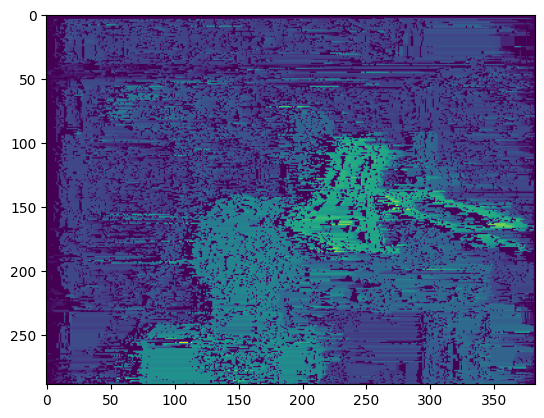

In [216]:
plot_disparityMap(l1,r1)

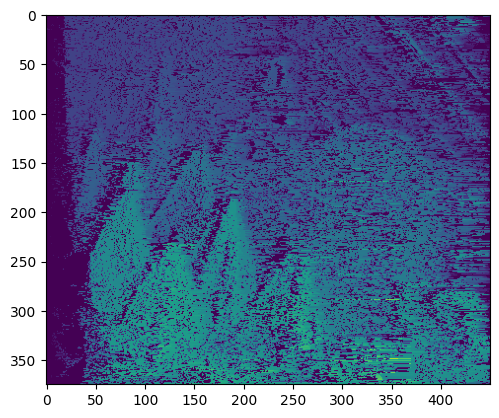

In [202]:
plot_disparityMap(l2,r2)

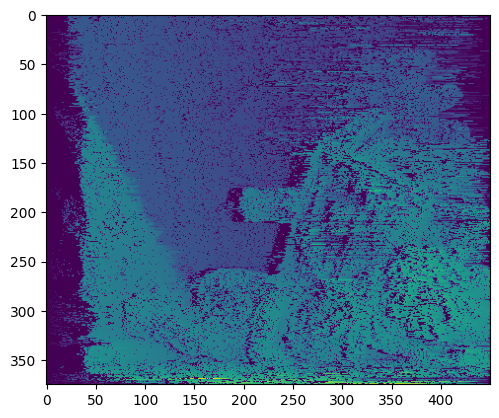

In [203]:
plot_disparityMap(l3,r3)